running 1000 ticks from scenario '/home/wilso/github/rustyecon/data/scenarios/multi_region'
Building 0: margin=0.000, margin_delta=0.000, p_adj=0.000, d_adj=0.000, last_throughput=35.00, chosen=35.00
--
Building 1: margin=0.000, margin_delta=0.000, p_adj=0.000, d_adj=0.000, last_throughput=35.00, chosen=35.00
--
Building 2: margin=0.000, margin_delta=0.000, p_adj=0.000, d_adj=0.000, last_throughput=35.00, chosen=35.00
--
Building 3: margin=-0.100, margin_delta=-0.100, p_adj=-0.057, d_adj=-0.019, last_throughput=10.00, chosen=10.00
--
Building 4: margin=-0.100, margin_delta=-0.100, p_adj=-0.057, d_adj=-0.019, last_throughput=10.00, chosen=10.00
--
Building 5: margin=-0.100, margin_delta=-0.100, p_adj=-0.057, d_adj=-0.019, last_throughput=10.00, chosen=10.00
--
Building 6: margin=-0.100, margin_delta=-0.100, p_adj=-0.057, d_adj=-0.019, last_throughput=10.00, chosen=10.00
--
Building 7: margin=-0.100, margin_delta=-0.100, p_adj=-0.057, d_adj=-0.019, last_throughput=10.00, chosen=10.00
--


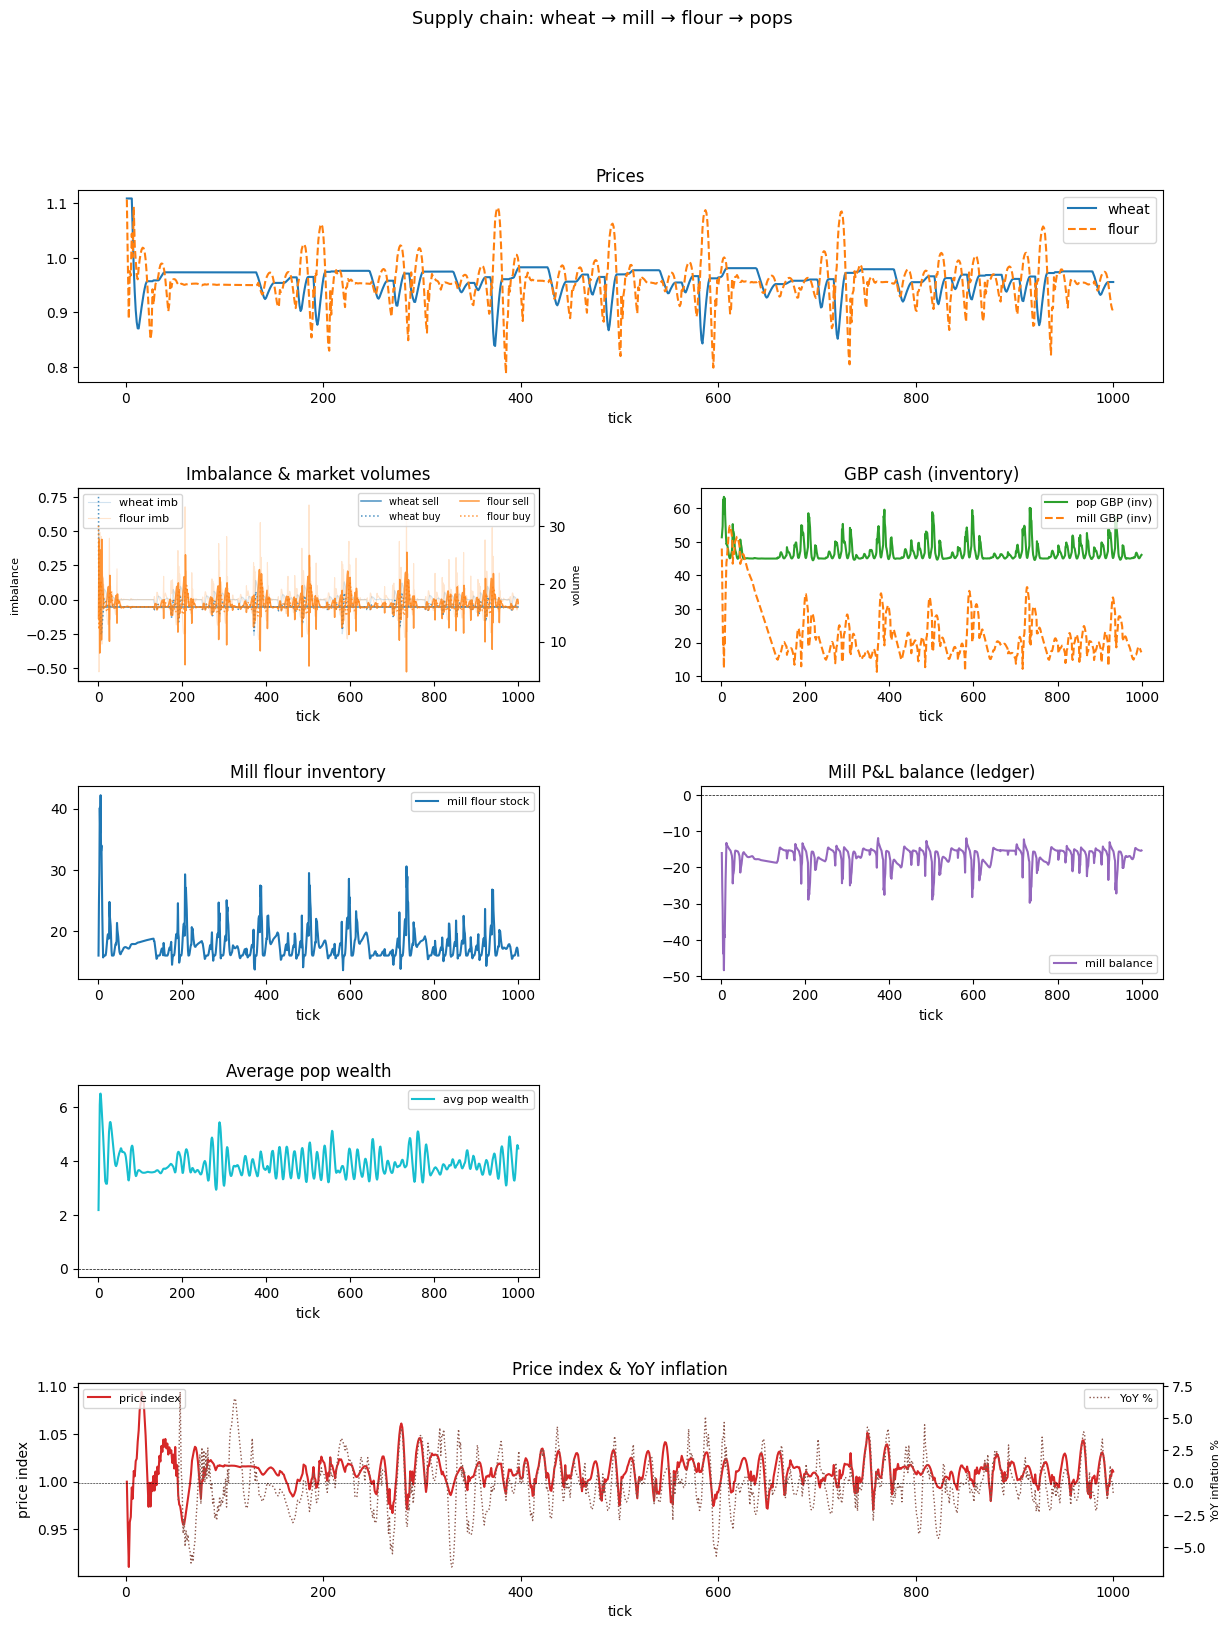

In [2]:
"""
rustyecon — supply chain sim

Manchester: MagicProducer(wheat) → grain mill → flour → pops.
UBI=10 GBP/tick. savings_target=0.75.

Set PLOTS = True to render figures (or copy to a .ipynb to see them inline).
"""

import sys
from pathlib import Path

_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "Cargo.toml").exists())
sys.path.insert(0, str(_root / "tools"))

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from scenario import run_simulation, load_scenario
from readers import load_scenario_results, ScenarioResults

# ── settings ──────────────────────────────────────────────────────────────────
PLOTS    = True
SCENARIO = "multi_region"
TICKS    = 1000
OUTPUT   = _root / "tmp" / SCENARIO

NODE = 0
# ─────────────────────────────────────────────────────────────────────────────


def load() -> ScenarioResults:
    gd = load_scenario(SCENARIO)
    return load_scenario_results(OUTPUT, gd)


def print_stats(res: ScenarioResults) -> None:
    wheat_p   = res.prices_for("wheat", node_id=NODE)
    flour_p   = res.prices_for("flour", node_id=NODE)
    wheat_imb = res.volume_for("wheat", "imbalance", node_id=NODE)
    flour_imb = res.volume_for("flour", "imbalance", node_id=NODE)
    pop_gbp   = res.inventory_for("pop", 0, "GBP")
    pi        = res.price_index()
    yoy       = res.yoy_inflation()
    bal       = res.building_series(0, "balance") if not res.buildings.empty else None

    print("=== prices, GBP & inflation (selected ticks) ===")
    print(
        f"{'tick':>5}  {'wheat p':>8}  {'flour p':>8}"
        f"  {'wheat imb':>10}  {'flour imb':>10}"
        f"  {'pop GBP':>9}  {'price idx':>10}  {'yoy %':>7}"
    )
    nan = float("nan")
    ticks_to_show = list(range(1, 20)) + [49, 50, 51, 52, 55, 60, 70, 100, TICKS]
    for t in ticks_to_show:
        if t not in wheat_p.index:
            continue
        print(
            f"{t:>5}  {wheat_p.get(t, nan):>8.4f}  {flour_p.get(t, nan):>8.4f}"
            f"  {wheat_imb.get(t, nan):>10.4f}  {flour_imb.get(t, nan):>10.4f}"
            f"  {pop_gbp.get(t, nan):>9.2f}"
            f"  {pi.get(t, nan):>10.4f}  {yoy.get(t, nan):>7.2f}"
        )

    if not pi.empty:
        print(f"\nprice index range: [{pi.min():.4f}, {pi.max():.4f}]")
        print(f"peak price index:  {pi.max():.4f} at tick {pi.idxmax()}")

    if bal is not None and not bal.empty:
        print("\n=== mill (building 0) P&L balance (selected ticks) ===")
        print(f"{'tick':>5}  {'balance':>12}")
        for t in ticks_to_show:
            if t in bal.index:
                print(f"{t:>5}  {bal.loc[t]:>12.4f}")
        print(f"\nbalance range: [{bal.min():.4f}, {bal.max():.4f}]")
    else:
        print("\n(no buildings data — run with --human-save 1)")

    avg_wealth = res.pop_wealth_by_region()
    if not avg_wealth.empty:
        print("\n=== average pop wealth (selected ticks) ===")
        print(f"{'tick':>5}  {'avg wealth':>12}")
        for t in ticks_to_show:
            if t in avg_wealth.index:
                print(f"{t:>5}  {avg_wealth.loc[t]:>12.4f}")
        print(f"\nwealth range: [{avg_wealth.min():.4f}, {avg_wealth.max():.4f}]")

    last = res.inventories["tick"].max() if not res.inventories.empty else None
    if last is not None:
        print(f"\n=== building inventories at tick {last} ===")
        snap = res.inventories[
            (res.inventories["entity_type"] == "building") &
            (res.inventories["tick"] == last)
        ]
        for _, row in snap.iterrows():
            name = res.good_name.get(int(row["good_id"]), f"good{int(row['good_id'])}")
            print(f"  bld {int(row['entity_id'])}  {name:>5}: {row['qty']:.2f}")


def plot(res: ScenarioResults) -> None:
    wheat_p   = res.prices_for("wheat", node_id=NODE).reset_index()
    flour_p   = res.prices_for("flour", node_id=NODE).reset_index()
    wheat_imb = res.volume_for("wheat", "imbalance", node_id=NODE).reset_index()
    flour_imb = res.volume_for("flour", "imbalance", node_id=NODE).reset_index()
    wheat_s   = res.volume_for("wheat", "supply",    node_id=NODE).reset_index()
    wheat_d   = res.volume_for("wheat", "demand",    node_id=NODE).reset_index()
    flour_s   = res.volume_for("flour", "supply",    node_id=NODE).reset_index()
    flour_d   = res.volume_for("flour", "demand",    node_id=NODE).reset_index()
    pop_gbp   = res.inventory_for("pop", 0, "GBP").reset_index()
    bld_gbp   = res.inventory_for("building", 0, "GBP").reset_index()
    mill_flour= res.inventory_for("building", 0, "flour").reset_index()
    bal_df    = (res.buildings[res.buildings["building_id"] == 0][["tick", "balance"]]
                 if not res.buildings.empty else None)
    pi        = res.price_index().reset_index()
    pi.columns = ["tick", "price_index"]
    yoy       = res.yoy_inflation().dropna().reset_index()
    yoy.columns = ["tick", "yoy_inflation_pct"]
    avg_wealth = res.pop_wealth_by_region().reset_index()
    avg_wealth.columns = ["tick", "wealth"]

    fig = plt.figure(figsize=(14, 18))
    fig.suptitle("Supply chain: wheat → mill → flour → pops", fontsize=13)
    gs = gridspec.GridSpec(5, 2, figure=fig, hspace=0.55, wspace=0.35)

    # Row 0: prices
    ax1 = fig.add_subplot(gs[0, :])
    ax1.plot(wheat_p["tick"], wheat_p["price"], label="wheat", lw=1.5)
    ax1.plot(flour_p["tick"], flour_p["price"], label="flour", lw=1.5, ls="--")
    ax1.set_title("Prices")
    ax1.set_xlabel("tick")
    ax1.legend()

    # Row 1 left: imbalance + supply/demand volumes
    ax2 = fig.add_subplot(gs[1, 0])
    ax2.plot(wheat_imb["tick"], wheat_imb["imbalance"], label="wheat imb", lw=0.8, alpha=0.2)
    ax2.plot(flour_imb["tick"], flour_imb["imbalance"], label="flour imb", lw=0.8, alpha=0.2)
    ax2.set_title("Imbalance & market volumes")
    ax2.set_xlabel("tick")
    ax2.set_ylabel("imbalance", fontsize=8)
    if not wheat_s.empty:
        ax2r = ax2.twinx()
        ax2r.plot(wheat_s["tick"], wheat_s["supply"],  color="tab:blue",   lw=1.1, alpha=0.8, ls="-",  label="wheat sell")
        ax2r.plot(wheat_d["tick"], wheat_d["demand"],  color="tab:blue",   lw=1.1, alpha=0.8, ls=":",  label="wheat buy")
        ax2r.plot(flour_s["tick"], flour_s["supply"],  color="tab:orange", lw=1.1, alpha=0.8, ls="-",  label="flour sell")
        ax2r.plot(flour_d["tick"], flour_d["demand"],  color="tab:orange", lw=1.1, alpha=0.8, ls=":",  label="flour buy")
        ax2r.set_ylabel("volume", fontsize=8)
        ax2r.legend(loc="upper right", fontsize=7, ncol=2)
    ax2.legend(loc="upper left", fontsize=8)

    # Row 1 right: GBP cash inventory
    ax3 = fig.add_subplot(gs[1, 1])
    if not pop_gbp.empty:
        ax3.plot(pop_gbp["tick"], pop_gbp["qty"], lw=1.5, color="tab:green",  label="pop GBP (inv)")
    if not bld_gbp.empty:
        ax3.plot(bld_gbp["tick"], bld_gbp["qty"], lw=1.5, color="tab:orange", ls="--", label="mill GBP (inv)")
    ax3.set_title("GBP cash (inventory)")
    ax3.set_xlabel("tick")
    ax3.legend(fontsize=8)

    # Row 2 left: mill flour inventory
    ax4 = fig.add_subplot(gs[2, 0])
    if not mill_flour.empty:
        ax4.plot(mill_flour["tick"], mill_flour["qty"], lw=1.5, label="mill flour stock")
    ax4.set_title("Mill flour inventory")
    ax4.set_xlabel("tick")
    ax4.legend(fontsize=8)

    # Row 2 right: mill P&L balance
    ax5 = fig.add_subplot(gs[2, 1])
    if bal_df is not None and not bal_df.empty:
        ax5.axhline(0, color="k", lw=0.5, ls="--")
        ax5.plot(bal_df["tick"], bal_df["balance"], lw=1.5, color="tab:purple", label="mill balance")
        ax5.legend(fontsize=8)
    else:
        ax5.text(0.5, 0.5, "no RON data\n(run with --human-save 1)", ha="center", va="center",
                 transform=ax5.transAxes, fontsize=9, color="grey")
    ax5.set_title("Mill P&L balance (ledger)")
    ax5.set_xlabel("tick")

    # Row 3 left: average pop wealth
    ax_w = fig.add_subplot(gs[3, 0])
    if not avg_wealth.empty:
        ax_w.plot(avg_wealth["tick"], avg_wealth["wealth"], lw=1.5, color="tab:cyan", label="avg pop wealth")
        ax_w.axhline(0, color="k", lw=0.5, ls="--")
        ax_w.legend(fontsize=8)
    else:
        ax_w.text(0.5, 0.5, "no RON data", ha="center", va="center",
                  transform=ax_w.transAxes, fontsize=9, color="grey")
    ax_w.set_title("Average pop wealth")
    ax_w.set_xlabel("tick")

    # Row 3 right: placeholder
    ax_spare = fig.add_subplot(gs[3, 1])
    ax_spare.axis("off")

    # Row 4: price index + YoY inflation
    ax6 = fig.add_subplot(gs[4, :])
    if not pi.empty:
        ax6_r = ax6.twinx()
        ax6.plot(pi["tick"], pi["price_index"], lw=1.5, color="tab:red", label="price index")
        if not yoy.empty:
            ax6_r.plot(yoy["tick"], yoy["yoy_inflation_pct"], lw=1.0,
                       color="tab:brown", ls=":", label="YoY %")
            ax6_r.axhline(0, color="k", lw=0.4, ls="--")
            ax6_r.set_ylabel("YoY inflation %", fontsize=8)
            ax6_r.legend(loc="upper right", fontsize=8)
        ax6.set_ylabel("price index")
        ax6.legend(loc="upper left", fontsize=8)
    else:
        ax6.text(0.5, 0.5, "no price data", ha="center", va="center",
                 transform=ax6.transAxes, fontsize=9, color="grey")
    ax6.set_title("Price index & YoY inflation")
    ax6.set_xlabel("tick")

    out = OUTPUT / "plot.png"
    plt.savefig(out, dpi=150, bbox_inches="tight")
    print(f"\nsaved -> {out}")
    plt.show()


if __name__ == "__main__":
    result = run_simulation(SCENARIO, TICKS, output_dir=str(OUTPUT),
                            human_save_every=1, build=True)
    if result.returncode != 0:
        print(result.stderr)
        raise SystemExit(1)
    print(result.stdout)

    res = load()
    print_stats(res)
    if PLOTS:
        plot(res)
